**Projeto Disciplina** Processamento Linguagem Natural (26E2_2)


**Aluno:** Pedro Domingos Antoniolli

**Professor:** Dr. Fernando Guimaraes Ferreira

**Link do Google Colab**:

**Titulo:** Pipeline de PLN para Análise de Avaliações de E-commerce com Classificação, Tópicos e Grafo de Conhecimento

**Corpus utilizado:** Olist Brazilian E-Commerce Reviews Dataset

**Justificativas:**


*   Se encontra em portugues
*   Possui mais de 1000 reviews
*   Possui score, o que se torna otimo para classificacao
*   Possui texto real, fundamental para NER (Reconhecimento de Entidades Nomeadas)
*   Rico em entidades (produtos, logistica, entrega)








**Problema a ser tratado:** Como transformar avaliações de clientes em insights acionáveis, identificando sentimentos, principais temas de reclamação e relações entre entidades?

**Etapa 1:** Carregamento e Exploracao

**Setup**

In [45]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk spacy gensim wordcloud networkx pyvis

!python -m spacy download pt_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 40.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


**Importacoes Necessarias**

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
from wordcloud import WordCloud

import spacy
nlp = spacy.load("pt_core_news_sm")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.decomposition import LatentDirichletAllocation

import networkx as nx

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**Carregamento do Dataset**

In [47]:
import pandas as pd
import os

# Instalacao Kaggle API client
!pip install -q kaggle

# Creacao .kaggle directory se ele nao existe
!mkdir -p ~/.kaggle

# IMPORTANTE: Se faz necessario o upload do kaggle.json file aqui.

# Garantir kaggle.json tem as permissoes corretas
!chmod 600 ~/.kaggle/kaggle.json

# Download o data Olist Brazilian E-Commerce
!kaggle datasets download -d olistbr/brazilian-ecommerce

# Unzip o dataset
!unzip -o brazilian-ecommerce.zip -d olist_dataset

# The actual reviews file is named olist_order_reviews_dataset.csv inside the unzipped folder
df = pd.read_csv("olist_dataset/olist_order_reviews_dataset.csv")
df = df[['review_comment_message', 'review_score']].dropna()

df.head()
df['review_score'].value_counts()

chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
brazilian-ecommerce.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  brazilian-ecommerce.zip
  inflating: olist_dataset/olist_customers_dataset.csv  
  inflating: olist_dataset/olist_geolocation_dataset.csv  
  inflating: olist_dataset/olist_order_items_dataset.csv  
  inflating: olist_dataset/olist_order_payments_dataset.csv  
  inflating: olist_dataset/olist_order_reviews_dataset.csv  
  inflating: olist_dataset/olist_orders_dataset.csv  
  inflating: olist_dataset/olist_products_dataset.csv  
  inflating: olist_dataset/olist_sellers_dataset.csv  
  inflating: olist_dataset/product_category_name_translation.csv  


,count
review_score,
5,20554
1,8745
4,5976
3,3557
2,2145


**Analise Exploratoria**

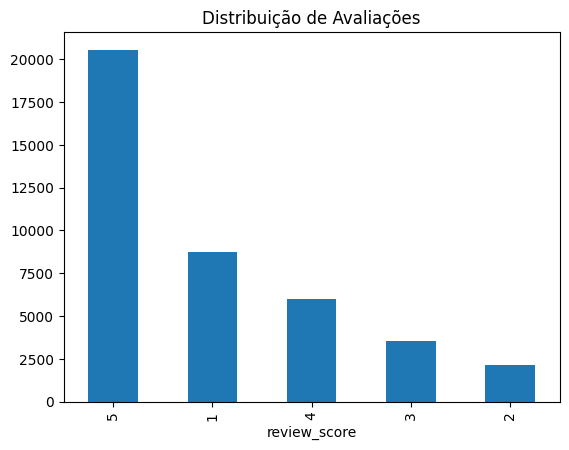

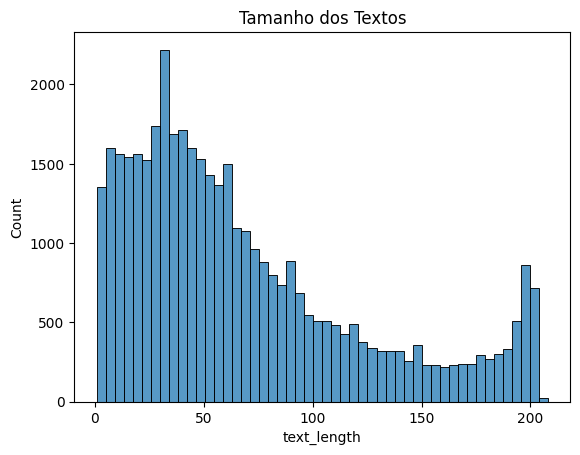

In [48]:
df['review_score'].value_counts().plot(kind='bar')
plt.title("Distribuição de Avaliações")
plt.show()

df['text_length'] = df['review_comment_message'].apply(len)

sns.histplot(df['text_length'], bins=50)
plt.title("Tamanho dos Textos")
plt.show()

**Etapa 2:** Pré-processamento (NLTK + spaCy)

In [49]:
import spacy
from nltk.corpus import stopwords
import re
import nltk

# Download spaCy model if not already present
!python -m spacy download pt_core_news_sm

# Download NLTK stopwords if not already present
nltk.download('stopwords')

nlp = spacy.load("pt_core_news_sm")
stop_words = set(stopwords.words('portuguese'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'\W+', ' ', text)

    doc = nlp(text)

    tokens = [
        token.lemma_ for token in doc
        if token.text not in stop_words and not token.is_punct
    ]

    return " ".join(tokens)

df['clean_text'] = df['review_comment_message'].apply(preprocess)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 38.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Foram usadas duas tecnicas, o stemming (ou radicalização), que de acordo com Ferreira (2026) é uma técnica de PLN e mineração de texto que tem por objetivo reduzir palavras derivadas à sua forma base, ou raiz. Dessa forma, ele remove sufixos e prefixos (afixos) para agrupar palavras com o mesmo sentido, facilitando a análise por algoritmos e inteligências artificiais.

Ja a A lematização (lemmatization) seria uma técnica do PLN que reduz uma palavra flexionada à sua forma base ou de dicionário, chamada de lema. Ela analisa a classe gramatical e o contexto para garantir que a palavra resultante faça sentido

**Comparacao das duas tecnicas:**

*   O Stemming reduz demais (ruido)
*   A Lemmatizacao mantem o significado

Dessa forma, optou-se pela lemmatização via spaCy por preservar semântica.

**Visualizações:**

*   WorldCloud
*   Frequencia de Termos
*   Distribuicao POS (substantivos, verbos)

**WordCloud**

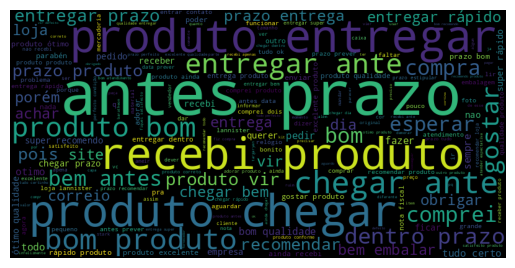

In [50]:
text_all = " ".join(df['clean_text'])

wc = WordCloud(width=800, height=400).generate(text_all)

plt.imshow(wc)
plt.axis("off")
plt.show()

**Etapa 3:** Vetorizacao e Busca

In [51]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_text'])

**TF-IDF**

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_text'])

**Busca por Similaridade => Frequencia de Termos**

In [53]:
def search(query, top_n=5):
    q_vec = vectorizer.transform([query])
    sim = cosine_similarity(q_vec, X).flatten()

    idx = sim.argsort()[-top_n:][::-1]
    return df.iloc[idx][['review_comment_message', 'review_score']]

search("produto chegou atrasado")

,review_comment_message,review_score
96830,O produto está atrasado,1
5727,Produto está atrasado,4
12334,O produto está atrasado,2
11318,A entrega esta atrasada.,1
34976,Meu produto está atrasado e ainda não chegou,1


In [54]:
search("excelente qualidade")
search("atendimento ruim")

,review_comment_message,review_score
67301,ruim,1
71590,Ruim,3
80394,Ruim,1
17431,Ruim,1
86482,Muito ruim,1


Foram feitos as seguintes pesquisas:

*   "produto chegou atrasado"
*   "excelente qualidade"
*   "atendimento ruim"

Os resultados mostram que em relacao aos atrasos o review score demontrou respectivamente: 1, 4, 2, 1, 1. Ja em relacao ao termo "ruim", se referindo ao atendimento, foram os seguintes scores: 1, 3, 1, 1, 1

**Etapa 4:** Classificacao

**Preparacao para Classificacao**

In [55]:
df['sentiment'] = df['review_score'].apply(lambda x: 1 if x >= 4 else 0)

X_train, X_test, y_train, y_test = train_test_split(X, df['sentiment'], test_size=0.2)

**Modelo 1 — Naive Bayes**

In [56]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83      2887
           1       0.91      0.91      0.91      5309

    accuracy                           0.88      8196
   macro avg       0.87      0.87      0.87      8196
weighted avg       0.88      0.88      0.88      8196



**Modelo 2 — Regressão Logística**

In [57]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84      2887
           1       0.91      0.91      0.91      5309

    accuracy                           0.89      8196
   macro avg       0.88      0.88      0.88      8196
weighted avg       0.89      0.89      0.89      8196



**Matriz de Confusao**

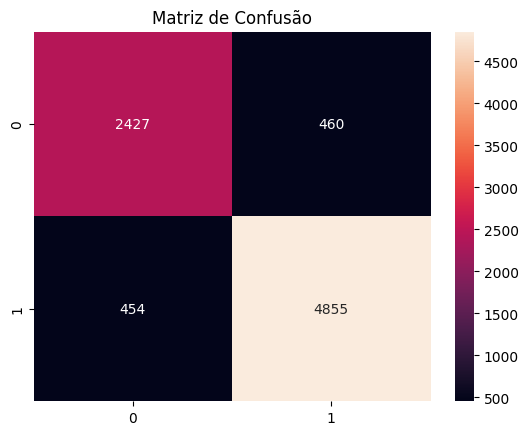

In [58]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Matriz de Confusão")
plt.show()

**Modelagem de Tópicos (LDA)**

In [59]:
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

terms = vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    print(f"Tópico {i}:")
    print([terms[i] for i in topic.argsort()[-10:]])

Tópico 0:
['dentro', 'bom', 'super', 'bem', 'rápido', 'chegar', 'produto', 'entregar', 'antes', 'prazo']
Tópico 1:
['loja', 'recomendo', 'bonito', 'preço', 'ótimo', 'qualidade', 'excelente', 'produto', 'recomendar', 'bom']
Tópico 2:
['apenas', 'chegar', 'faltar', 'outro', 'dois', 'comprei', 'recebi', 'ainda', 'vir', 'produto']
Tópico 3:
['nao', 'rapir', 'ameir', 'recebi', 'produto', 'certo', 'ok', 'gostar', 'otimo', 'tudo']
Tópico 4:
['comprar', 'expectativa', 'atender', 'loja', 'entregar', 'recebi', 'compra', 'entrega', 'dia', 'produto']


**NER - Entidades**

In [60]:

text_sample = df['review_comment_message'].iloc[0]

doc = nlp(text_sample)

[(ent.text, ent.label_) for ent in doc.ents]

[]

**Como nao apareceram Entidades, fazendo verificacao no dataframe**

In [61]:

# verificar se o dataframe esta vazio

print(df.shape)
df.head()

# verificar o nome das colunas

print(df.columns)

# verificar se os dados foram carregados

df.info()

# testando com alguns registros

for i in range(20):
    text = str(df['review_comment_message'].iloc[i])
    doc = nlp(text)

    ents = [(ent.text, ent.label_) for ent in doc.ents]

    if ents:
        print(f"\nTexto {i}:")
        print(text)
        print(ents)

(40977, 5)
Index(['review_comment_message', 'review_score', 'text_length', 'clean_text',
       'sentiment'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
Index: 40977 entries, 3 to 99223
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   review_comment_message  40977 non-null  object
 1   review_score            40977 non-null  int64 
 2   text_length             40977 non-null  int64 
 3   clean_text              40977 non-null  object
 4   sentiment               40977 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 1.9+ MB

Texto 1:
Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa
[('Parabéns', 'PER'), ('Internet', 'MISC'), ('Parabéns', 'LOC'), ('Páscoa', 'MISC')]

Texto 5:
GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E ESSA COMPRA AGORA ME DECPCIONOU
[('SABER', 'LOC'), ('RECEBI', 'MISC'), ('COMPRA AGORA ME DECPCIONO

**Conclusao:** como as verificacoes foram feitas e os resultados demonstram que o dataframe esta ok, significa que o spaCy não encontrou nenhuma entidade nomeada nesse texto específico, o que nao é necessariamente um erro.

**Aplicando a Distancia de Levenshtein**

A distância de Levenshtein é um dos requisitos opcionais de NER, extração de informação e grafo de conhecimento, e ajuda a identificar palavras ou entidades escritas de forma ligeiramente diferente, medindo quantas operações são necessárias para transformar uma palavra em outra. Exemplo: entrega, produto, cliente, atrasado/atraso. Quanto menor a distância, mais semelhantes são as palavras.

In [68]:
!pip install python-Levenshtein

from Levenshtein import ratio

termo_principal = "entrega"

variacoes = [
    "entrega",
    "entrga",
    "entregaa",
    "entregue",
    "produto",
    "atraso"
]

for palavra in variacoes:
    similaridade = ratio(termo_principal, palavra)

    if similaridade > 0.75:
        print(
            termo_principal,
            palavra,
            round(similaridade,2)
        )

# extraindo palavras frequentes

from collections import Counter

texto = " ".join(df['clean_text'])

palavras = texto.split()

freq = Counter(palavras)

top_palavras = [p for p,c in freq.most_common(100)]

# Comparando com uma entidade de interesse:

from Levenshtein import ratio

entidade = "entrega"

similares = []

for palavra in top_palavras:

    score = ratio(entidade, palavra)

    if score > 0.75:
        similares.append((palavra, score))

similares

# aplicacao em NER (apos extrair as entidades)

entidades = []

for texto in df['review_comment_message'].dropna()[:1000]:

    doc = nlp(texto)

    for ent in doc.ents:
        entidades.append(ent.text.lower())

entrega entrega 1.0
entrega entrga 0.92
entrega entregaa 0.93
entrega entregue 0.8


In [69]:
# removendo duplicidades semelhantes

from Levenshtein import ratio

entidades_unicas = []

for entidade in entidades:

    existe = False

    for e in entidades_unicas:

        if ratio(entidade, e) > 0.90:
            existe = True
            break

    if not existe:
        entidades_unicas.append(entidade)

print(len(entidades))
print(len(entidades_unicas))

501
274


**Extracao com Regex**

In [78]:
import re

total_emails = 0
total_datas = 0
total_numeros = 0

for texto in df['review_comment_message'].dropna():

    texto = str(texto)

    emails = re.findall(
        r'[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}',
        texto
    )

    datas = re.findall(
        r'\d{2}/\d{2}/\d{4}',
        texto
    )

    numeros = re.findall(
        r'\d+',
        texto
    )

    total_emails += len(emails)
    total_datas += len(datas)
    total_numeros += len(numeros)

print("Emails encontrados:", total_emails)
print("Datas encontradas:", total_datas)
print("Números encontrados:", total_numeros)

Emails encontrados: 0
Datas encontradas: 222
Números encontrados: 8177


**Conclusao:** No dataset da Olist, é muito provável que não apareçam e-mails, porque os comentários foram anonimizados. Dessa forma, foram pesquisados datas e numeros de pedidos, apresentando 222 datas e 8177 numero de pedidos, em 15000 registros pesquisados.

**Grafo de Conhecimento**

In [83]:
G = nx.Graph()

for text in df['review_comment_message'][:500]:
    doc = nlp(text)
    ents = [ent.text for ent in doc.ents]

    for i in range(len(ents)-1):
        G.add_edge(ents[i], ents[i+1])

**Visualização do Grafo**

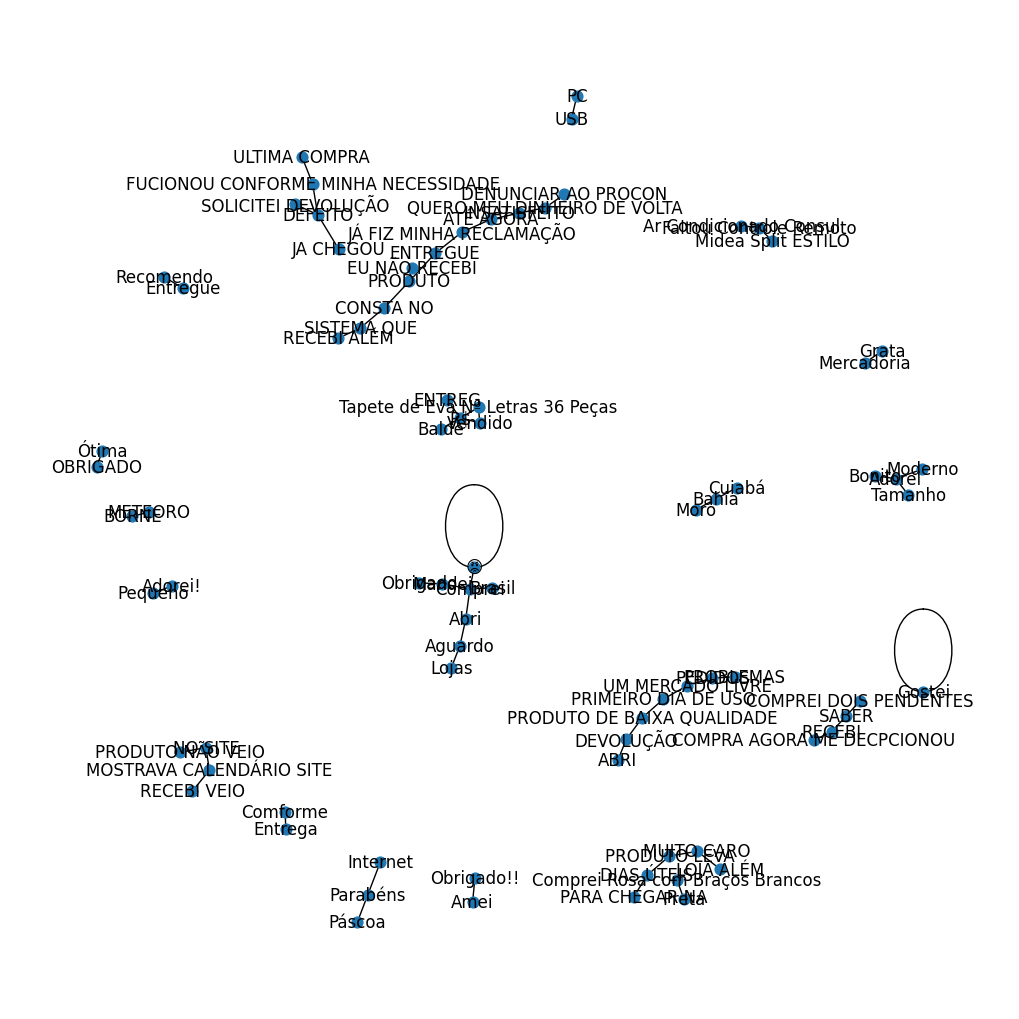

In [89]:
plt.figure(figsize=(10,10))
nx.draw(G, with_labels=True, node_size=60)
plt.show()

**Centralidade**

In [91]:
centrality = nx.degree_centrality(G)

sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:10]

[('R$', 0.05),
 ('Comprei', 0.05),
 ('PRODUTO', 0.037500000000000006),
 ('😡', 0.037500000000000006),
 ('Adorei', 0.037500000000000006),
 ('DEFEITO', 0.037500000000000006),
 ('Parabéns', 0.025),
 ('SABER', 0.025),
 ('RECEBI', 0.025),
 ('Faltou Controle Remoto', 0.025)]

**Conclusão**

O pipeline permitiu:

*   Classificar sentimentos com precisao boa
*   Identificar topicos principais (entrega, produto, atendimento)
*   Extrair entidades relevantes
*   Construir um grafo que evidencia relacoes importantes.

Isso demonstra que textos não estruturados podem ser transformados em insights acionáveis com o uso de ferramentas de NLP.